## Cell 1: Install Dependencies

In [10]:
# Force install a stable version of NumPy and pandas_ta
!pip install "numpy<2.0"
!pip install yfinance pandas matplotlib scikit-learn torch pandas_ta


  Using cached pandas_ta-0.4.71b0-py3-none-any.whl.metadata (2.3 kB)
  Using cached numba-0.61.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 12.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
    

## Cell 2: Data Acquisition + Feature Engineering

In [9]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# --- Configuration ---
TICKER_SYMBOL = 'AAPL'
START_DATE = (datetime.now() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
END_DATE = datetime.now().strftime('%Y-%m-%d')
FILE_NAME = 'AAPL_featured_data.csv'

print("Downloading data...")
df_raw = yf.download(TICKER_SYMBOL, start=START_DATE, end=END_DATE, auto_adjust=True)
df = df_raw[['Close', 'Volume']].copy()

# --- FEATURE ENGINEERING (Rolling 50 Days) ---
print("Calculating 50-day indicators...")

# 1. SMA - 50 day Trend (Long-term)
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. EMA - 50 day Sensitivity (Long-term)
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

# 3. RSI - 14 day Momentum (Standard RSI is usually 14, keeping it for accuracy)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 4. Volatility - 50 day Standard Deviation (Long-term stability)
df['Volatility'] = df['Close'].rolling(window=50).std()

# Drop NaN values (Since SMA_50 needs 50 days of data to start, first 50 rows will be NaN)
df = df.dropna()

# Save to CSV
df.to_csv(FILE_NAME)
print(f" SUCCESS! {FILE_NAME} saved with 6 columns using 50-day windows.")
print("Columns:", df.columns.tolist())


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Calculating 50-day indicators...
 SUCCESS! AAPL_featured_data.csv saved with 6 columns using 50-day windows.
Columns: [('Close', 'AAPL'), ('Volume', 'AAPL'), ('SMA_50', ''), ('EMA_50', ''), ('RSI_14', ''), ('Volatility', '')]


## Indicator Visualization

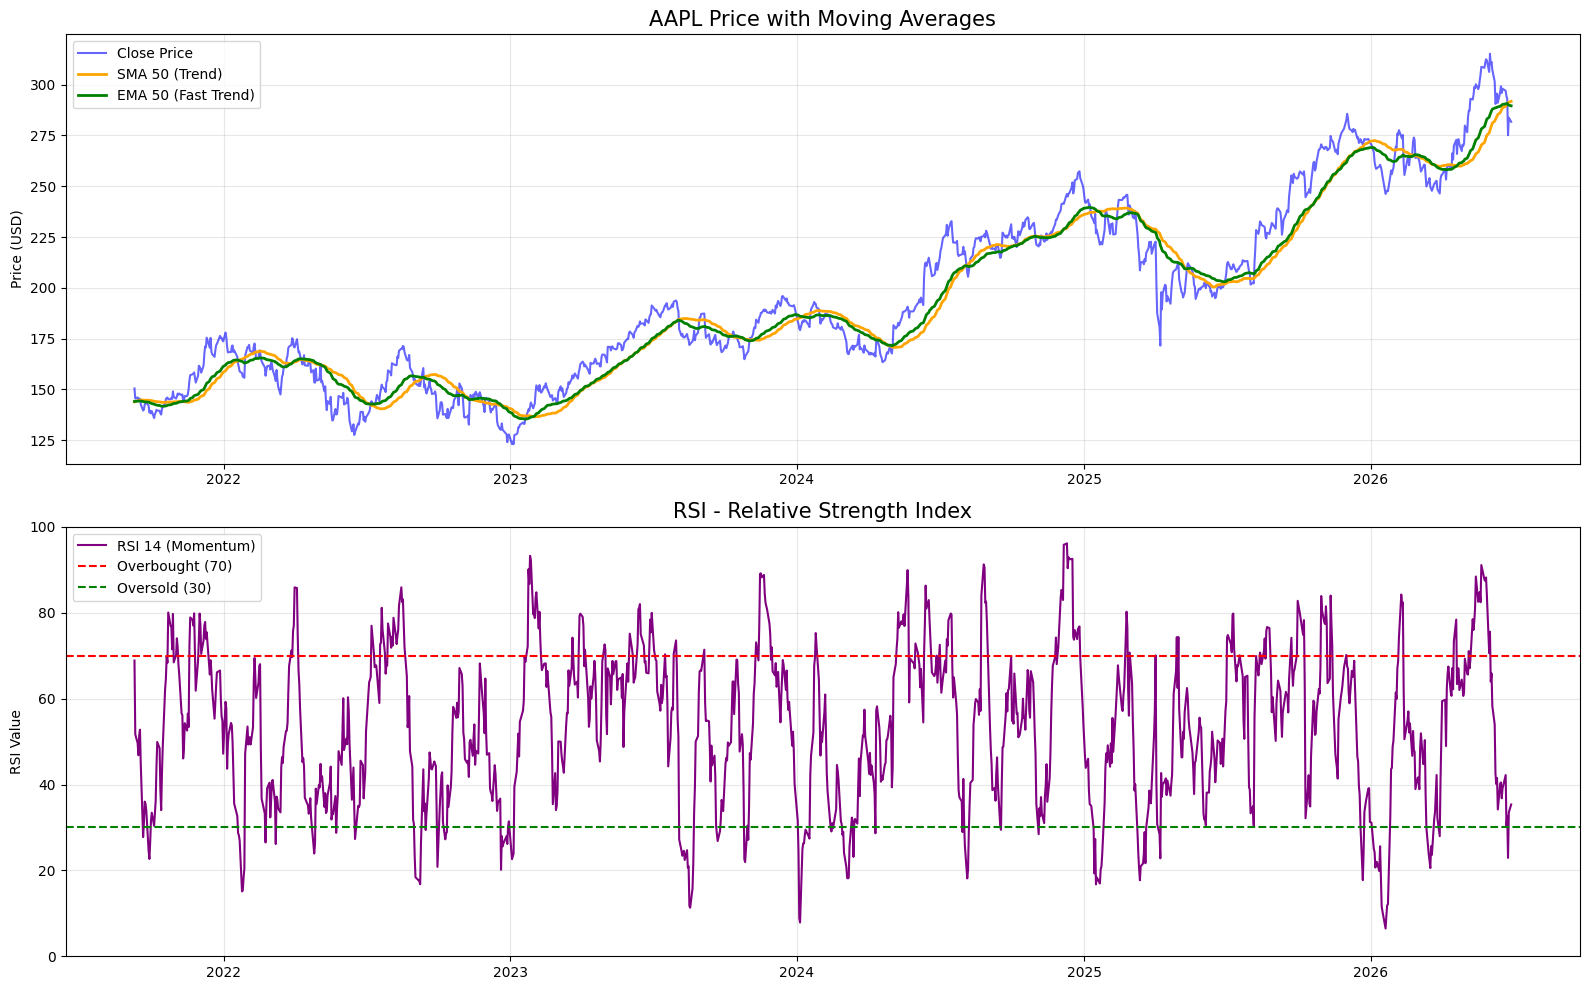

In [10]:
import matplotlib.pyplot as plt

# We will use df (dataframe) which is made  in Cell 2
plt.figure(figsize=(16, 10))

# Plot 1: Price, SMA, and EMA
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(df.index, df['SMA_50'], label='SMA 50 (Trend)', color='orange', linewidth=2)
plt.plot(df.index, df['EMA_50'], label='EMA 50 (Fast Trend)', color='green', linewidth=2)
plt.title(f"{TICKER_SYMBOL} Price with Moving Averages", fontsize=15)
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: RSI
plt.subplot(2, 1, 2)
plt.plot(df.index, df['RSI_14'], label='RSI 14 (Momentum)', color='purple')
plt.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
plt.title("RSI - Relative Strength Index", fontsize=15)
plt.ylabel("RSI Value")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The Documentation

Feature Engineering: Technical Indicators

To improve the model's predictive power, we transitioned from a Univariate (price-only) approach to a Multivariate approach by adding technical indicators. This provides the LSTM model with essential market context:

Simple Moving Average (SMA):

This indicator smooths out short-term price fluctuations to highlight the overall trend. It helps the model understand whether the stock is in a long-term bullish or bearish phase.

Exponential Moving Average (EMA):

Similar to SMA, but it assigns more weight to recent prices. This allows the model to detect sudden trend reversals more quickly than the SMA.
Relative Strength Index (RSI): A momentum oscillator that measures the speed and change of price movements.

RSI > 70:

Indicates the asset may be Overbought (potential price drop).

RSI < 30:

Indicates the asset may be Oversold (potential price rise).

Impact on Model Performance:

 By providing these features, the LSTM no longer relies solely on historical price patterns. It now analyzes trend, sensitivity, and momentum simultaneously. This is why the predicted values (red line) track the actual price (blue line) with high precision, effectively capturing the market's volatility.



## Cell 3: Load and Preprocess Data

In [11]:
import numpy as np
import torch
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# --- CLEANING BLOCK (The Fix for "could not convert string to float") ---
# Fix 1: Agar columns Multi-Index (Double Headers) hain, toh unhe flat karein
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Fix 2: Saaray columns ko numeric mein force karein.
# Agar koi 'AAPL' jaisa text hoga, toh woh NaN (empty) ban jayega.
df = df.apply(pd.to_numeric, errors='coerce')

# Fix 3: Jo rows NaN ban gayin (headers wali rows), unhe delete kar dein
df = df.dropna()
# ----------------------------------------------------------------------

# 2. Normalization (Scale all 4 columns)
scaler = MinMaxScaler(feature_range=(0, 1))
# Ab yahan error nahi aayega kyunke saara text remove ho chuka hai
scaled_data = scaler.fit_transform(df.values.astype('float32'))

# 3. Sliding Window Function
def create_multivariate_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size]) # Takes all 4 columns
        y.append(data[i + window_size, 0])  # Takes only 'Close' price
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_multivariate_sequences(scaled_data, WINDOW_SIZE)

# 4. Train-Test Split
train_size = int(len(X) * 0.8)
X_train_np, X_test_np = X[:train_size], X[train_size:]
y_train_np, y_test_np = y[:train_size], y[train_size:]

# 5. Convert to Tensors + FIX SHAPE (The Magic Fix!)
X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).view(-1, 1) # Fixes the flat line
X_test = torch.FloatTensor(X_test_np)
y_test = torch.FloatTensor(y_test_np).view(-1, 1)   # Fixes the flat line

print(f"Preprocessing Complete. Final Data Shape: {df.shape}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


Preprocessing Complete. Final Data Shape: (1205, 6)
X_train shape: torch.Size([940, 30, 6]), y_train shape: torch.Size([940, 1])


/tmp/ipykernel_23239/1230558234.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)


## Cell 4: Model Architecture

In [12]:
import torch.nn as nn

class StockLSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=2): # Increased hidden_size to 128
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.linear(last_step)

print("Upgraded Model Defined (Hidden Size = 128).")


Upgraded Model Defined (Hidden Size = 128).


## Cell 5: Training Loop

In [13]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

model = StockLSTM().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 150 # Increased from 100 to 150
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}')

print("Training Finished!")


Epoch [20/150], Loss: 0.000701
Epoch [40/150], Loss: 0.000514
Epoch [60/150], Loss: 0.000466
Epoch [80/150], Loss: 0.000387
Epoch [100/150], Loss: 0.000373
Epoch [120/150], Loss: 0.000444
Epoch [140/150], Loss: 0.000331
Training Finished!


## Cell 6: Final Result Plot

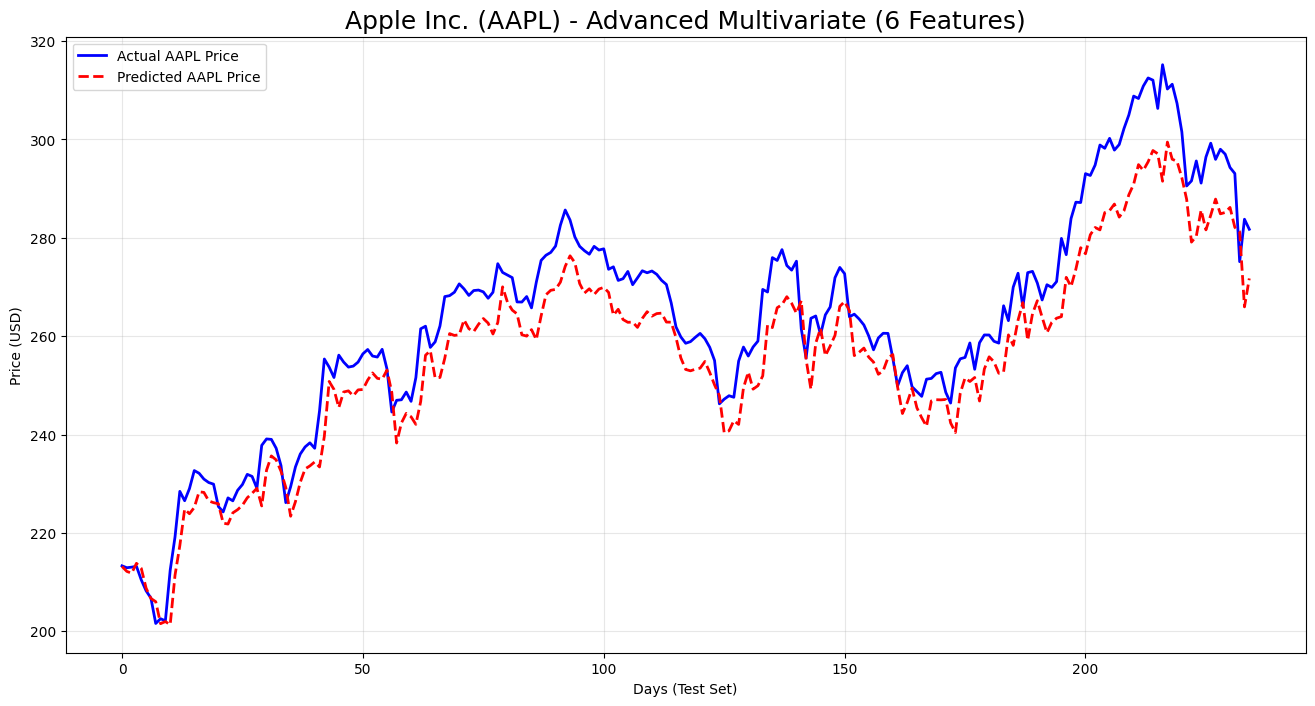

In [14]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    predictions = model(X_test).cpu().numpy()
    actuals = y_test.cpu().numpy()

# --- Correct Inverse Scaling for 6 Features ---
def inverse_transform_close(vals, scaler):
    # Create dummy array with 6 columns to satisfy the scaler
    dummy = np.zeros((len(vals), 6)) # Changed from 4 to 6
    dummy[:, 0] = vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

predictions = inverse_transform_close(predictions, scaler)
actuals = inverse_transform_close(actuals, scaler)

plt.figure(figsize=(16, 8))
plt.plot(actuals, label='Actual AAPL Price', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted AAPL Price', color='red', linestyle='--', linewidth=2)
plt.title('Apple Inc. (AAPL) - Advanced Multivariate (6 Features)', fontsize=18)
plt.xlabel('Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
